<a href="https://colab.research.google.com/github/alixHub-ux/data_analysis/blob/main/Examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
# Charger les fichiers depuis le drive
train_df = pd.read_csv('/content/drive/MyDrive/deep_learning /diabetes.csv')
test_df = pd.read_csv('/content/drive/MyDrive/deep_learning /diabete_test.csv')


In [ ]:
# Afficher les informations
print(f" Train shape: {train_df.shape}")
print(f" Test shape: {test_df.shape}")

print("\n Aperçu des données d'entraînement:")
print(train_df.head())

print("\n Distribution de la variable Outcome (train):")
print(train_df['Outcome'].value_counts())

 Train shape: (768, 9)
 Test shape: (768, 9)

 Aperçu des données d'entraînement:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

 Distribution de la variable Outcome (train):
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparer features (X) et target (y) pour l'entraînement
X_train_full = train_df.drop('Outcome', axis=1)
y_train_full = train_df['Outcome']

# Créer un ensemble de validation (20% du train)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# Préparer les données de test
X_test = test_df.drop('Outcome', axis=1)
y_test = test_df['Outcome']

# Normaliser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n Dimensions après préparation:")
print(f"X_train: {X_train_scaled.shape}")
print(f"X_val: {X_val_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")


 Dimensions après préparation:
X_train: (614, 8)
X_val: (154, 8)
X_test: (768, 8)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Créer le modèle
model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compiler
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Callback pour arrêter si pas d'amélioration
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Entraînement
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5267 - loss: 0.6845 - val_accuracy: 0.6818 - val_loss: 0.6448
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6592 - loss: 0.6452 - val_accuracy: 0.7013 - val_loss: 0.6000
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7489 - loss: 0.5771 - val_accuracy: 0.6883 - val_loss: 0.5493
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7189 - loss: 0.5682 - val_accuracy: 0.7078 - val_loss: 0.5231
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7551 - loss: 0.5306 - val_accuracy: 0.7143 - val_loss: 0.5062
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7537 - loss: 0.5160 - val_accuracy: 0.7208 - val_loss: 0.4995
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7464 - loss: 0.5195 - val_accuracy: 0.7338 - val_loss: 0.4952
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7654 - loss: 0.5002 - val_accuracy: 0.7403 - 


🎯 RÉSULTATS FINAUX SUR LE FICHIER TEST:
Test Accuracy: 78.52%
Test Loss: 0.4485
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📊 Classification Report:
                    precision    recall  f1-score   support

Pas de diabète (0)       0.81      0.88      0.84       500
       Diabète (1)       0.73      0.60      0.66       268

          accuracy                           0.79       768
         macro avg       0.77      0.74      0.75       768
      weighted avg       0.78      0.79      0.78       768



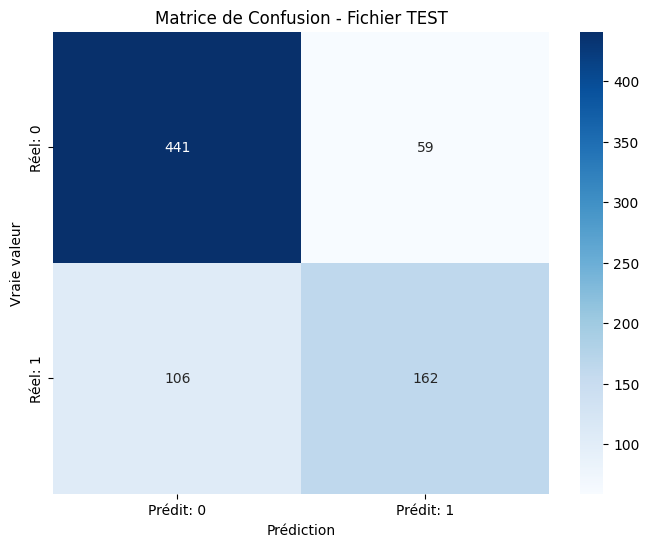

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Évaluation sur le fichier TEST
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n🎯 RÉSULTATS FINAUX SUR LE FICHIER TEST:")
print(f"=" * 50)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Prédictions
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Rapport détaillé
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Pas de diabète (0)', 'Diabète (1)']))

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: 0', 'Prédit: 1'],
            yticklabels=['Réel: 0', 'Réel: 1'])
plt.title('Matrice de Confusion - Fichier TEST')
plt.ylabel('Vraie valeur')
plt.xlabel('Prédiction')
plt.show()
